In [2]:
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
DATASET_ROOT = Path("../data/raw/breakhis/BreaKHis_v1/histology_slides/breast")

IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg", ".tif")

image_paths = []
for root, dirs, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.lower().endswith(IMAGE_EXTENSIONS):
            image_paths.append(os.path.join(root, file))

print("Total images available:", len(image_paths))


Total images available: 7909


Sample image path: ..\data\raw\breakhis\BreaKHis_v1\histology_slides\breast\benign\SOB\adenosis\SOB_B_A_14-22549AB\100X\SOB_B_A-14-22549AB-100-001.png


(np.float64(-0.5), np.float64(699.5), np.float64(459.5), np.float64(-0.5))

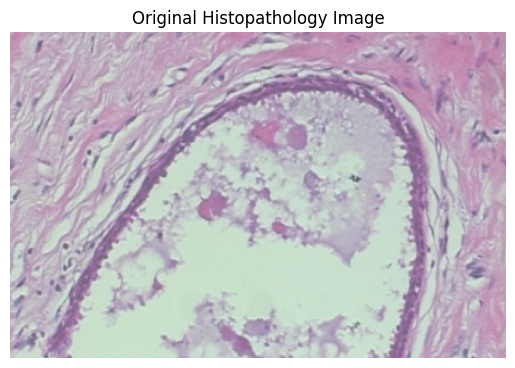

In [4]:
sample_image_path = image_paths[0]
print("Sample image path:", sample_image_path)

img_rgb = cv2.imread(sample_image_path)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Histopathology Image")
plt.axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

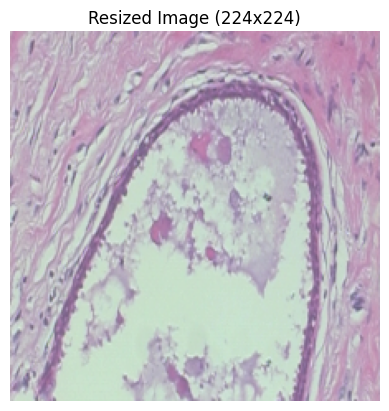

In [5]:
IMG_SIZE = 224

img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

plt.imshow(img_resized)
plt.title("Resized Image (224x224)")
plt.axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

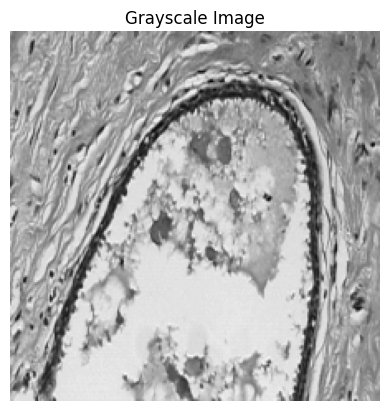

In [6]:
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

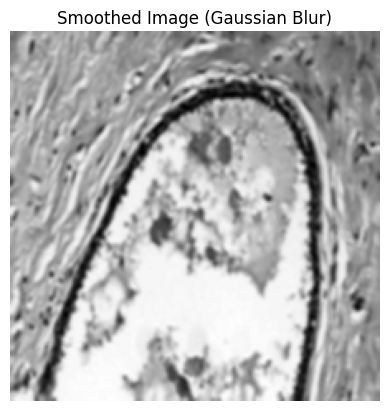

In [7]:
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

plt.imshow(img_blur, cmap="gray")
plt.title("Smoothed Image (Gaussian Blur)")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

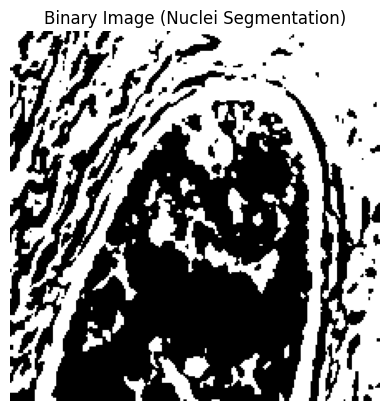

In [8]:
_, img_thresh = cv2.threshold(
    img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.imshow(img_thresh, cmap="gray")
plt.title("Binary Image (Nuclei Segmentation)")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

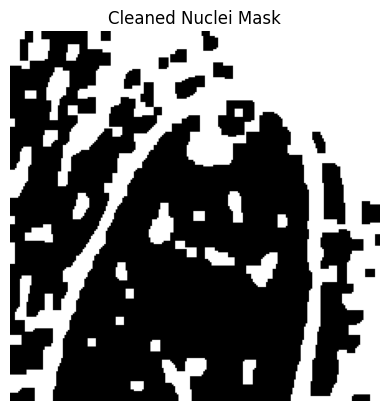

In [9]:
kernel = np.ones((3, 3), np.uint8)

img_open = cv2.morphologyEx(img_thresh, cv2.MORPH_OPEN, kernel, iterations=2)
img_close = cv2.morphologyEx(img_open, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.imshow(img_close, cmap="gray")
plt.title("Cleaned Nuclei Mask")
plt.axis("off")


Number of detected nuclei: 28


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

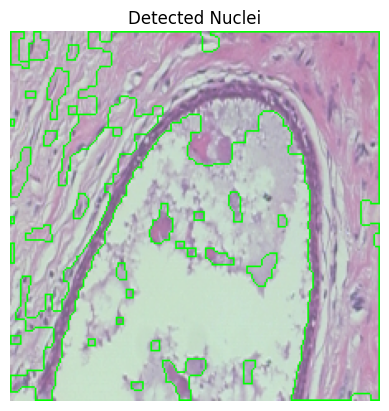

In [10]:
contours, _ = cv2.findContours(
    img_close, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

print("Number of detected nuclei:", len(contours))

img_nuclei = img_resized.copy()
cv2.drawContours(img_nuclei, contours, -1, (0, 255, 0), 1)

plt.imshow(img_nuclei)
plt.title("Detected Nuclei")
plt.axis("off")


In [11]:
areas = [cv2.contourArea(cnt) for cnt in contours if cv2.contourArea(cnt) > 0]

cell_density = len(areas) / (IMG_SIZE * IMG_SIZE)
avg_nucleus_size = np.mean(areas) if areas else 0
size_variance = np.var(areas) if areas else 0

print("Cell density:", round(cell_density, 4))
print("Average nucleus size:", round(avg_nucleus_size, 2))
print("Nucleus size variance:", round(size_variance, 2))


Cell density: 0.0006
Average nucleus size: 788.07
Nucleus size variance: 13139917.23


In [12]:
behavior_features = {
    "cell_density": float(cell_density),
    "avg_nucleus_size": float(avg_nucleus_size),
    "nuclear_abnormality": float(size_variance)
}

behavior_features


{'cell_density': 0.0005580357142857143,
 'avg_nucleus_size': 788.0714285714286,
 'nuclear_abnormality': 13139917.227040818}

In [13]:
## Phase 2B: Cellular Graph Construction from Detected Nuclei

In [14]:
centroids = []

for cnt in contours:
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        centroids.append((cx, cy))

print("Number of graph nodes (nuclei):", len(centroids))


Number of graph nodes (nuclei): 28


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

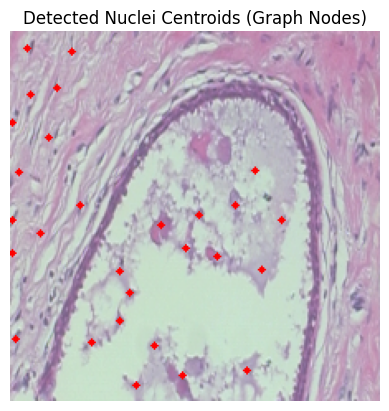

In [15]:
img_nodes = img_resized.copy()

for (x, y) in centroids:
    cv2.circle(img_nodes, (x, y), 2, (255, 0, 0), -1)

plt.imshow(img_nodes)
plt.title("Detected Nuclei Centroids (Graph Nodes)")
plt.axis("off")

In [16]:
node_features = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if perimeter > 0:
        circularity = 4 * np.pi * area / (perimeter ** 2)
    else:
        circularity = 0

    node_features.append([area, perimeter, circularity])

node_features = np.array(node_features)

print("Node feature matrix shape:", node_features.shape)


Node feature matrix shape: (28, 3)


In [17]:
from scipy.spatial.distance import euclidean

EDGE_DISTANCE_THRESHOLD = 30  # pixels (tunable)

edges = []

for i, c1 in enumerate(centroids):
    for j, c2 in enumerate(centroids):
        if i != j:
            dist = euclidean(c1, c2)
            if dist <= EDGE_DISTANCE_THRESHOLD:
                edges.append((i, j, dist))

print("Number of edges created:", len(edges))


Number of edges created: 62


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

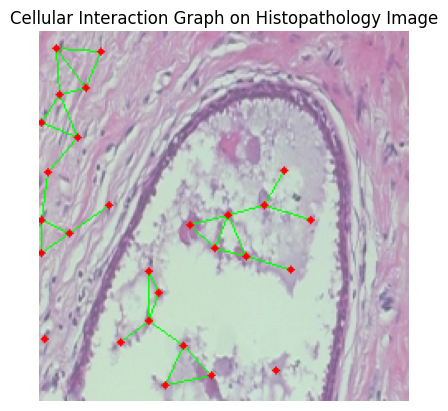

In [18]:
img_graph = img_resized.copy()

for (i, j, d) in edges:
    pt1 = centroids[i]
    pt2 = centroids[j]
    cv2.line(img_graph, pt1, pt2, (0, 255, 0), 1)

for (x, y) in centroids:
    cv2.circle(img_graph, (x, y), 2, (255, 0, 0), -1)

plt.imshow(img_graph)
plt.title("Cellular Interaction Graph on Histopathology Image")
plt.axis("off")


In [19]:
print("Graph Summary")
print("Nodes (cells):", len(centroids))
print("Edges (cell interactions):", len(edges))


Graph Summary
Nodes (cells): 28
Edges (cell interactions): 62


In [20]:
edge_index = [(i, j) for i, j, _ in edges]
edge_weights = [d for _, _, d in edges]

cellular_graph = {
    "node_features": node_features,
    "edge_index": edge_index,
    "edge_weights": edge_weights,
    "positions": centroids
}

print("Cellular graph data prepared.")


Cellular graph data prepared.


In [21]:
import pickle
import os

os.makedirs("../outputs/graphs", exist_ok=True)

with open("../outputs/graphs/cellular_graph.pkl", "wb") as f:
    pickle.dump(cellular_graph, f)

print("Cellular graph saved.")


Cellular graph saved.
